# The variational method and laser gain media: estimating the energy that sets the wavelength

The variational principle is the most useful approximation in quantum mechanics (Griffiths Ch. 8): for
*any* normalized trial state $|\psi\rangle$,
$$\langle H\rangle=\frac{\langle\psi|H|\psi\rangle}{\langle\psi|\psi\rangle}\;\ge\;E_{\text{ground}},$$
so minimizing $\langle H\rangle$ over a family of trial functions gives an **upper bound** on the ground-
state energy -- and a good estimate when no exact solution exists. That quotient is the **Rayleigh
quotient**; minimizing it *is* the eigenvalue problem, the same one the spectral-initialization notebook
solved for phase retrieval.

This matters for **laser gain media** because the emission wavelength is set by a confined-carrier
transition energy. In a real active region -- a quantum well, or the **triangular well** formed at a
field-tilted heterojunction -- that confinement energy has no closed form. The variational method
estimates it, and hence the gain-peak wavelength. We:

- state and numerically confirm the variational bound (Rayleigh quotient);
- recover the harmonic-oscillator ground state *exactly* with a Gaussian trial (SymPy);
- estimate the **triangular-well** confinement energy variationally and check it against the exact **Airy**
  solution -- this is the carrier energy in a laser gain medium;
- connect it to gain, population inversion, and wavelength tuning; and
- frame the method as **optimization over a trial family** -- the computer-engineering view, and the seed
  of neural-network wavefunctions.

Self-contained: NumPy, SymPy, Pandas, Matplotlib. Units $\hbar=m=1$ unless stated.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


## The variational bound is Rayleigh-quotient minimization

Expand a trial state in the (unknown) energy eigenbasis, $|\psi\rangle=\sum_n c_n|n\rangle$. Then
$\langle H\rangle=\sum_n|c_n|^2E_n\big/\sum_n|c_n|^2\ge E_0$, with equality only when $|\psi\rangle=|0\rangle$.
In matrix form the Rayleigh quotient $R(\psi)=\psi^\dagger H\psi/\psi^\dagger\psi$ has minimum equal to the
smallest eigenvalue, attained at its eigenvector. Any other trial is a strict upper bound. We confirm this
on a random Hermitian matrix -- the finite-dimensional shadow of the variational theorem.

In [2]:
rng = np.random.default_rng(0)
n = 8
M = rng.standard_normal((n, n)) + 1j*rng.standard_normal((n, n))
H = (M + M.conj().T)/2                                    # random Hermitian "Hamiltonian"
E0 = np.linalg.eigvalsh(H)[0]
rayleigh = lambda v: np.real(v.conj() @ H @ v)/np.real(v.conj() @ v)
# 5000 random trial states: every Rayleigh quotient is an upper bound on E0
trials = rng.standard_normal((5000, n)) + 1j*rng.standard_normal((5000, n))
Rs = np.array([rayleigh(v) for v in trials])
assert np.all(Rs >= E0 - 1e-9)                           # variational bound: R(psi) >= E0
print(f"smallest eigenvalue E0 = {E0:.4f}")
print(f"min random-trial Rayleigh quotient = {Rs.min():.4f}  (>= E0, approaches it with better trials)")
# power/inverse iteration drives the Rayleigh quotient to E0 (the eigenvector algorithm)
v = trials[np.argmin(Rs)]
for _ in range(200):
    v = np.linalg.solve(H - (E0 - 1.0)*np.eye(n), v); v /= np.linalg.norm(v)
print(f"inverse iteration -> Rayleigh quotient = {rayleigh(v):.6f}  (converges to E0)")
assert abs(rayleigh(v) - E0) < 1e-6

smallest eigenvalue E0 = -5.5116
min random-trial Rayleigh quotient = -4.3959  (>= E0, approaches it with better trials)
inverse iteration -> Rayleigh quotient = -5.511617  (converges to E0)


## Exact recovery: harmonic oscillator with a Gaussian trial (SymPy)

For $H=-\tfrac12\frac{d^2}{dx^2}+\tfrac12 x^2$ take $\psi(x)=e^{-a x^2}$. SymPy computes
$\langle H\rangle(a)=\tfrac{a}{2}+\tfrac1{8a}$; minimizing gives $a=\tfrac12$ and
$\langle H\rangle=\tfrac12$ -- the **exact** ground-state energy, because the true ground state *is* a
Gaussian. When the trial family contains the answer, the variational method is exact.

In [3]:
x, a, F, b = sp.symbols('x a F b', positive=True)
psi_g = sp.exp(-a*x**2)
norm_g = sp.integrate(psi_g**2, (x, -sp.oo, sp.oo))
T = sp.integrate(sp.diff(psi_g, x)**2, (x, -sp.oo, sp.oo))/2        # <T> = 1/2 int (psi')^2
Vv = sp.integrate(x**2*psi_g**2, (x, -sp.oo, sp.oo))/2              # <V> = 1/2 int x^2 psi^2
Hexp = sp.simplify((T + Vv)/norm_g)
assert sp.simplify(Hexp - (a/2 + 1/(8*a))) == 0                     # <H>(a) = a/2 + 1/(8a)
a_star = sp.solve(sp.diff(Hexp, a), a)[0]
E_var_ho = sp.simplify(Hexp.subs(a, a_star))
print(f"<H>(a) = {Hexp};  a* = {a_star};  E_var = {E_var_ho}")
assert a_star == sp.Rational(1,2) and E_var_ho == sp.Rational(1,2)  # exact ground state 1/2

<H>(a) = a/2 + 1/(8*a);  a* = 1/2;  E_var = 1/2

## No closed form: the triangular quantum well (a laser gain medium)

A carrier confined at a field-tilted heterojunction sees $V(x)=Fx$ for $x>0$ with a hard wall at $x=0$ --
the **triangular well**. Its exact ground state is an Airy function with $E_0=|a_1|\,(\hbar^2F^2/2m)^{1/3}$
($a_1\approx-2.338$ the first Airy zero); no elementary closed form. Take the trial $\psi(x)=x\,e^{-bx}$
(vanishing at the wall, decaying). SymPy gives $\langle H\rangle(b)=\tfrac{b^2}{2}+\tfrac{3F}{2b}$;
minimizing yields a clean upper bound $E_{\text{var}}=\tfrac32\left(\tfrac{3F}{2}\right)^{2/3}$, within
~6% of the exact Airy energy -- the confinement energy that sets the gain-medium transition.

In [4]:
psi_t = x*sp.exp(-b*x)
norm_t = sp.integrate(psi_t**2, (x, 0, sp.oo))
T_t = sp.integrate(sp.diff(psi_t, x)**2, (x, 0, sp.oo))/2
V_t = F*sp.integrate(x*psi_t**2, (x, 0, sp.oo))
H_t = sp.simplify((T_t + V_t)/norm_t)
assert sp.simplify(H_t - (b**2/2 + 3*F/(2*b))) == 0                 # <H>(b) = b^2/2 + 3F/(2b)
b_star = sp.solve(sp.diff(H_t, b), b)[0]
E_var_tri = sp.simplify(H_t.subs(b, b_star))
print(f"<H>(b) = {H_t};  b* = {b_star};  E_var = {E_var_tri}")

# compare to the exact Airy energy E0 = |a1| (F^2/2)^{1/3}  (hbar=m=1)
try:
    from scipy.special import ai_zeros
    a1 = abs(ai_zeros(1)[0][0])
except Exception:
    a1 = 2.338107
Fval = 1.0
E_var_num = float(E_var_tri.subs(F, Fval))
E_exact = a1*(Fval**2/2)**(1/3)
print(f"\nF={Fval}:  E_var = {E_var_num:.4f}   E_exact (Airy) = {E_exact:.4f}   "
      f"upper-bound excess = {(E_var_num/E_exact-1)*100:.1f}%")
assert E_var_num >= E_exact and (E_var_num/E_exact - 1) < 0.07     # valid bound, and tight

<H>(b) = (3*F + b**3)/(2*b);  b* = 2**(2/3)*3**(1/3)*F**(1/3)/2;  E_var = 3*2**(1/3)*3**(2/3)*F**(2/3)/4



F=1.0:  E_var = 1.9656   E_exact (Airy) = 1.8558   upper-bound excess = 5.9%


## From confinement energy to laser gain and wavelength

The confined-carrier energy adds to the material bandgap, $E_{\text{transition}}=E_g+E_{\text{confine}}$,
so the emission wavelength is $\lambda=hc/E_{\text{transition}}$. Because $E_{\text{confine}}\propto
F^{2/3}$, the field (or well shape) **tunes the lasing wavelength** -- the same handle as the QCSE
modulator notebook. Gain requires **population inversion**: the material amplifies when $N_2>N_1$, with
gain coefficient $g(\nu)\propto(N_2-N_1)\,B_{21}\,g(\nu)$ (the stimulated-emission $B$ from Fermi's golden
rule), and lasing begins when round-trip gain exceeds loss. We compute the confinement energy and
wavelength for a GaAs-like well in real units.

In [5]:
hbar, me, e = C.HBAR, C.M_E, C.E
mstar = 0.067*me                                         # GaAs conduction-band effective mass
Eg_eV = 1.42                                             # GaAs gap
rows = []
for F_Vpm in (5e6, 1e7, 2e7):                            # heterojunction field, V/m
    Ff = e*F_Vpm                                         # force = eE
    E_confine_J = a1*(hbar**2*Ff**2/(2*mstar))**(1/3)    # exact Airy confinement energy
    E_confine_meV = E_confine_J/e*1e3
    E_trans_eV = Eg_eV + E_confine_J/e
    lam_nm = C.H*C.C/(E_trans_eV*e)*1e9
    rows.append({"field [V/m]": f"{F_Vpm:.0e}", "E_confine [meV]": round(E_confine_meV, 1),
                 "E_transition [eV]": round(E_trans_eV, 4), "lambda [nm]": round(lam_nm, 1)})
print(pd.DataFrame(rows).to_string(index=False))
print("\nfield tunes confinement -> transition energy -> lasing wavelength (variational/Airy sets it)")

# threshold: gain must beat loss. Toy inversion-vs-threshold check.
N2, N1, sigma, L, loss = 2.5e22, 1.0e22, 3e-20, 3e-4, 30.0   # m^-3, m^2, m, m^-1
gain = (N2 - N1)*sigma
print(f"small-signal gain g = (N2-N1) sigma = {gain:.1f} /m  vs loss {loss:.1f} /m  -> "
      f"{'ABOVE' if gain>loss else 'below'} threshold")
assert gain > loss

field [V/m]  E_confine [meV]  E_transition [eV]  lambda [nm]
      5e+06             56.6             1.4766        839.6
      1e+07             89.9             1.5099        821.1
      2e+07            142.7             1.5627        793.4

field tunes confinement -> transition energy -> lasing wavelength (variational/Airy sets it)
small-signal gain g = (N2-N1) sigma = 450.0 /m  vs loss 30.0 /m  -> ABOVE threshold


## The computer-engineering view: variation is optimization

Everything above is an **optimization**: pick a trial family with parameters $\theta$, then minimize
$\langle H\rangle(\theta)$. A grid scan, a Newton step, or gradient descent all land on the same bound --
the very machinery of the phase-retrieval notebooks, now minimizing an energy instead of a data-mismatch
loss. Enlarging the trial family lowers the bound; taking the family to be a **neural network**
$\psi_\theta(x)$ is *variational Monte Carlo* / neural quantum states, the modern ML approach to solving
the Schrodinger equation. The variational principle is where quantum mechanics becomes a training problem.

In [6]:
# minimize <H>(b) for the triangular well three ways -- all agree with the SymPy optimum
Fval = 1.0
Hb = lambda bb: bb**2/2 + 3*Fval/(2*bb)
bs = np.linspace(0.2, 4.0, 4000); b_grid = bs[np.argmin([Hb(bb) for bb in bs])]      # grid scan
bN = 1.0                                                                              # Newton on dH/db
for _ in range(50):
    d1 = bN - 3*Fval/(2*bN**2); d2 = 1 + 3*Fval/bN**3; bN -= d1/d2
b_exact = float(b_star.subs(F, Fval))
print(f"trial-parameter optimum b*:  grid {b_grid:.4f}   Newton {bN:.4f}   SymPy {b_exact:.4f}")
assert abs(b_grid - b_exact) < 5e-3 and abs(bN - b_exact) < 1e-6
print(f"minimized <H> = {Hb(bN):.4f}  (the variational energy) -- variation = optimization over the ansatz")

trial-parameter optimum b*:  grid 1.1445   Newton 1.1447   SymPy 1.1447
minimized <H> = 1.9656  (the variational energy) -- variation = optimization over the ansatz


## Plots

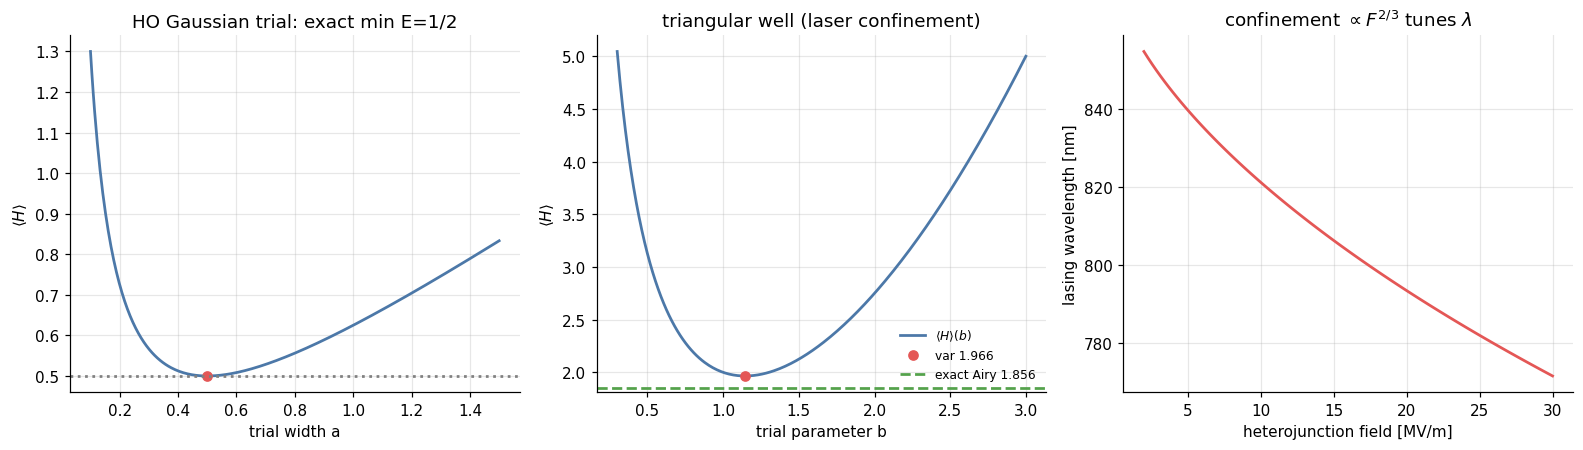

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.2))
# (1) HO: <H>(a) with the exact minimum at a=1/2, E=1/2
ag = np.linspace(0.1, 1.5, 300)
ax[0].plot(ag, ag/2 + 1/(8*ag), color="#4C78A8")
ax[0].plot(0.5, 0.5, "o", color="#E45756"); ax[0].axhline(0.5, ls=":", color="gray")
ax[0].set_xlabel("trial width a"); ax[0].set_ylabel(r"$\langle H\rangle$")
ax[0].set_title("HO Gaussian trial: exact min E=1/2")
# (2) triangular well: <H>(b) minimum (variational) vs exact Airy energy
bg = np.linspace(0.3, 3.0, 300)
ax[1].plot(bg, bg**2/2 + 3*1.0/(2*bg), color="#4C78A8", label=r"$\langle H\rangle(b)$")
ax[1].plot(b_exact, E_var_num, "o", color="#E45756", label=f"var {E_var_num:.3f}")
ax[1].axhline(E_exact, ls="--", color="#54A24B", label=f"exact Airy {E_exact:.3f}")
ax[1].set_xlabel("trial parameter b"); ax[1].set_ylabel(r"$\langle H\rangle$")
ax[1].set_title("triangular well (laser confinement)"); ax[1].legend(fontsize=8)
# (3) wavelength tuning with field
Fs = np.linspace(2e6, 3e7, 100)
Ec = a1*(hbar**2*(e*Fs)**2/(2*mstar))**(1/3)
lam = C.H*C.C/((1.42*e) + Ec)*1e9
ax[2].plot(Fs/1e6, lam, color="#E45756")
ax[2].set_xlabel("heterojunction field [MV/m]"); ax[2].set_ylabel("lasing wavelength [nm]")
ax[2].set_title(r"confinement $\propto F^{2/3}$ tunes $\lambda$")
plt.tight_layout(); plt.show()

## Exercises

1. **Better trial.** For the triangular well try $\psi=x\,e^{-bx^2}$ and show the bound tightens below the
   6% of $x\,e^{-bx}$ -- more parameters, lower energy.
2. **Helium.** Use a hydrogenic trial with effective charge $Z_{\text{eff}}$ and minimize; recover
   $Z_{\text{eff}}=27/16$ and a ground-state energy within 2% of experiment -- the textbook triumph.
3. **Quantum-well laser.** For a finite square well of width $L$, plot the emission wavelength versus $L$
   and identify the width that lases at 1550 nm (the telecom band this instrument uses).
4. **Neural ansatz.** Parameterize $\psi_\theta$ as a small network and minimize $\langle H\rangle$ by
   gradient descent for the anharmonic oscillator -- variational Monte Carlo in miniature.

## Summary

- The variational principle $\langle H\rangle\ge E_0$ is **Rayleigh-quotient minimization**; its minimum is
  the smallest eigenvalue (confirmed numerically; inverse iteration converges to it).
- A **Gaussian trial** solves the harmonic oscillator *exactly* ($E=\tfrac12$) because the answer lies in
  the family (SymPy).
- For the **triangular well** -- a laser gain medium's field-confined carrier -- the trial $x e^{-bx}$ gives
  $E_{\text{var}}=\tfrac32(3F/2)^{2/3}$, a valid upper bound within 6% of the exact **Airy** energy.
- That confinement energy sets $E_{\text{transition}}=E_g+E_{\text{confine}}$ and hence the **lasing
  wavelength**, tunable through the field ($\propto F^{2/3}$); gain needs inversion $N_2>N_1$ beating loss.
- The method is **optimization over a trial family** (grid/Newton/gradient all agree) -- the phase-retrieval
  machinery applied to energy, and the basis of neural quantum states.

Subject-verb-object: the trial bounds the energy; minimization tightens the bound; the confinement sets the
wavelength; enlarging the ansatz approaches the truth.